<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Overview_of_Colaboratory_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
print("x_train.shape:", x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train.shape: (60000, 28, 28)


In [3]:
# mais uma dimensão para o canal de cor
x_train = np.expand_dims(x_train, -1)# adicionando uma dimensão no final
x_test = np.expand_dims(x_test, -1)
print("x_train.shape:", x_train.shape)

x_train.shape: (60000, 28, 28, 1)


In [5]:
# Criando a CNN
i = Input(shape=x_train[0].shape)
K = 10
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i) # filtro que reduzirá as imagens pela metade
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x) # aumento no número de filtros
x = Flatten()(x) # camada de planarização

# Camada densa
x = Dropout(0.2)(x) # dropout para evitar overfitting
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x) #utilizamos a função softmax para a camada de saída

model = Model(i, x) # Criando o modelo

In [7]:
# compilando o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Treinamento
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.8903 - loss: 0.2932 - val_accuracy: 0.8842 - val_loss: 0.3155
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9006 - loss: 0.2643 - val_accuracy: 0.8928 - val_loss: 0.2934
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9075 - loss: 0.2427 - val_accuracy: 0.8961 - val_loss: 0.2912
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.9166 - loss: 0.2201 - val_accuracy: 0.9000 - val_loss: 0.3005
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9219 - loss: 0.2050 - val_accuracy: 0.8963 - val_loss: 0.2892
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9268 - loss: 0.1903 - val_accuracy: 0.8992 - val_loss: 0.2913
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9336 - loss: 0.1730 - val_accuracy: 0.9020 - val_loss: 0.3140
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9394 -

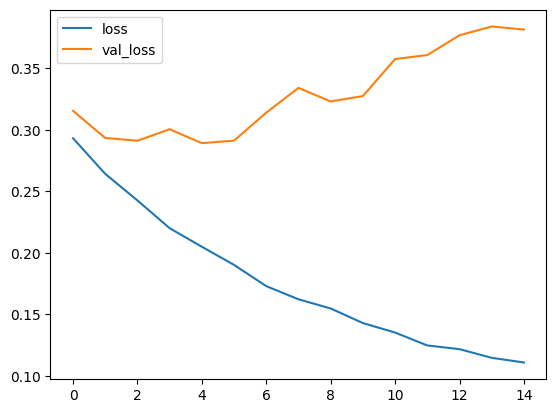

In [8]:
# resultados do treinamento
plt.plot(r.history['loss'], label='loss') # erros durante o treinamento
plt.plot(r.history['val_loss'], label='val_loss') # erros de validação
plt.legend()

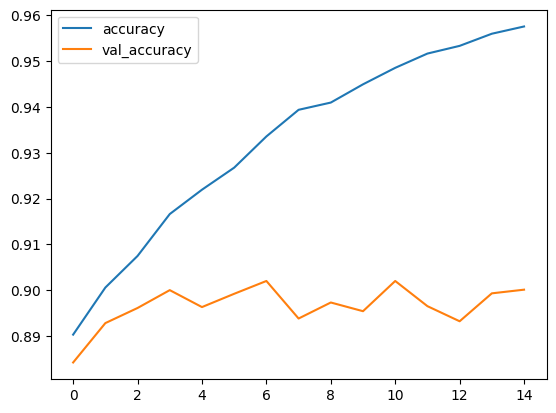

In [9]:
# acurácia do modelo
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy') # validação por época
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Confusion matrix, without normalization
[[844   3  27   9   3   2 107   0   5   0]
 [  1 980   2  12   2   0   1   0   2   0]
 [ 17   0 858  13  47   0  64   0   1   0]
 [ 15  10  17 891  33   2  30   0   2   0]
 [  0   0  59  25 835   0  77   0   4   0]
 [  0   0   1   0   0 976   0  17   0   6]
 [ 83   0  75  21  86   0 721   0  14   0]
 [  0   0   0   0   0  14   0 972   0  14]
 [  1   2   3   1   5   2   5   1 978   2]
 [  0   0   1   0   0   4   0  48   1 946]]


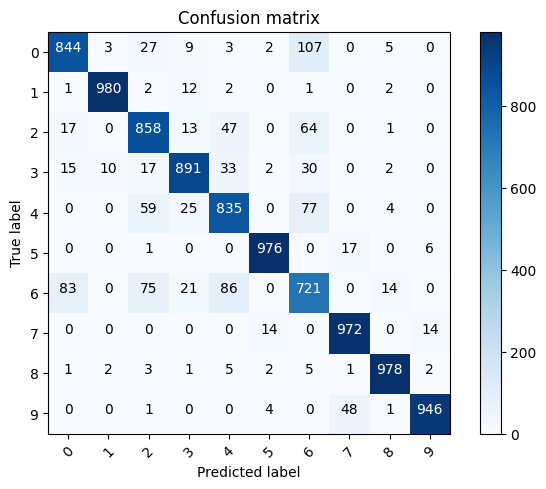

In [10]:
# matriz de confusão
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm,
                          classes, # Classes
                          normalize=False, # Normalização
                          title='Confusion matrix',
                          cmap=plt.cm.Blues # Cor
                          ):
    # normalização da matriz
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)

    # plotagem da matriz de confusão
    plt.imshow(cm, interpolation='nearest', cmap=cmap) # imagem da matriz
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # marcas
    plt.xticks(tick_marks, classes, rotation=45) # rotulos do eixo x
    plt.yticks(tick_marks, classes) # rotulos do eixo y

    # formatação dos números
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2. # limiar para a cor do texto

    # adicionando texto na matriz de confusão
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')

    # adicionando rótulos
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# predição
p_test = model.predict(x_test).argmax(axis=1)
# gerando a matriz
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [11]:
labels = '''T-shirt/top
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot'''.split()

Text(0.5, 1.0, 'True label: T-shirt/top Predicted: Shirt')

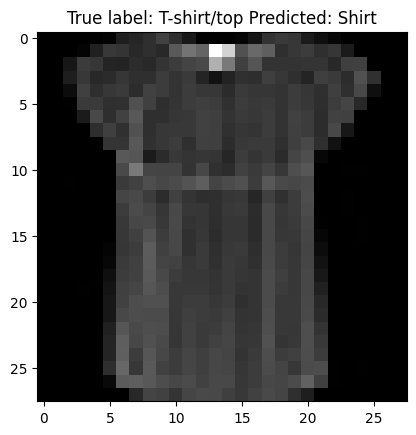

In [12]:
# mostrando a incoreta
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]))